# 64 — Construction-Only Feature Domain Fingerprinting

**Project:** AI VPN Firewall — Thesis
**Source pipeline:** Clean Pipeline (NB41-55)
**Goal:** Test whether flow construction statistics alone encode dataset identity.

---

## Rationale

The five lowest-level flow construction features — flow_duration, total_packets,
total_bytes, packet_rate, byte_rate — are computed directly from raw packet
timestamps and sizes **before** any statistical aggregation.

If a domain classifier trained on *only* these five features achieves high AUC,
it demonstrates that the construction pipeline itself encodes dataset identity,
meaning domain shift is present in the fundamental flow statistics, not just in
higher-order engineered features.

We use **capture-safe GroupKFold** (groups = capture_id) so no flows from the
same capture session appear in both train and test folds.

| Step | Detail |
|---|---|
| Features | flow_duration, total_packets, total_bytes, packet_rate, byte_rate |
| Target | dataset_id (multi-class) |
| CV | GroupKFold(n_splits=5, groups=capture_id) |
| Metric | OvR macro AUC |
| Comparison | Full-feature (21) domain AUC |

## 0. Setup

In [1]:
import sys, warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "figure.facecolor": "white"})

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

FEATURES_PATH = ROOT / "artifacts" / "clean_pipeline" / "features.parquet"
OUT = ROOT / "artifacts" / "thesis_finalization" / "nb64_construction_only_domain_fingerprinting"
FIG = OUT / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

SEED = 42
N_SPLITS = 5
N_EST = 200
print(f"Root: {ROOT}")

Root: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


---
## 1. Load Data & Define Feature Sets

In [2]:
from src.clean_pipeline.feature_families import get_family

FULL_FEATURES = list(get_family("safe_core_plus_temporal"))

CONSTRUCTION_FEATURES = [
    "flow_duration",
    "total_packets",
    "total_bytes",
    "packet_rate",
    "byte_rate",
]

df_all = pd.read_parquet(FEATURES_PATH)
DATASETS = sorted(df_all["dataset"].unique())

# Verify all features present
missing_c = [f for f in CONSTRUCTION_FEATURES if f not in df_all.columns]
missing_f = [f for f in FULL_FEATURES if f not in df_all.columns]
assert not missing_c, f"Missing construction features: {missing_c}"
assert not missing_f, f"Missing full features: {missing_f}"

print(f"Datasets:              {DATASETS}")
print(f"Total flows:           {len(df_all):,}")
print(f"Construction features: {len(CONSTRUCTION_FEATURES)}  {CONSTRUCTION_FEATURES}")
print(f"Full features:         {len(FULL_FEATURES)}")
print(f"Unique captures:       {df_all['capture_id'].nunique()}")

# Per-dataset summary
for ds in DATASETS:
    sub = df_all[df_all.dataset == ds]
    n_cap = sub["capture_id"].nunique()
    print(f"  {ds:8s}: {len(sub):>6,} flows, {n_cap:>3} captures")

Datasets:              ['iscx', 'usbvpn', 'vnat']
Total flows:           72,612
Construction features: 5  ['flow_duration', 'total_packets', 'total_bytes', 'packet_rate', 'byte_rate']
Full features:         21
Unique captures:       340
  iscx    : 11,801 flows, 140 captures
  usbvpn  : 52,704 flows,  35 captures
  vnat    :  8,107 flows, 165 captures


---
## 2. Capture-Safe Domain Classifier

Train XGBoost to predict `dataset_id` using GroupKFold(capture_id).
Run for both construction-only and full feature sets.

In [3]:
def capture_safe_domain_auc(df, feat_cols, n_splits=5, n_est=200, seed=42):
    """
    Capture-safe domain classification via GroupKFold.
    Returns per-fold results and overall macro AUC.
    """
    le = LabelEncoder()
    X = df[feat_cols].values
    y = le.fit_transform(df["dataset"].values)
    groups = df["capture_id"].values
    n_classes = len(le.classes_)

    n_unique = len(np.unique(groups))
    actual_splits = min(n_splits, n_unique)
    if actual_splits < 2:
        return {"mean_auc": float("nan"), "folds": [], "classes": list(le.classes_)}

    gkf = GroupKFold(n_splits=actual_splits)
    fold_results = []

    for fold_i, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        clf = xgb.XGBClassifier(
            n_estimators=n_est, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            eval_metric="mlogloss", random_state=seed,
            n_jobs=-1, verbosity=0,
        )
        clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
        prob = clf.predict_proba(X_te)
        y_pred = clf.predict(X_te)

        try:
            if n_classes == 2:
                auc = float(roc_auc_score(y_te, prob[:, 1]))
            else:
                auc = float(roc_auc_score(y_te, prob, multi_class="ovr", average="macro"))
        except Exception:
            auc = float("nan")

        acc = float(accuracy_score(y_te, y_pred))
        n_train_caps = len(np.unique(groups[tr_idx]))
        n_test_caps = len(np.unique(groups[te_idx]))

        fold_results.append({
            "fold": fold_i, "auc": auc, "accuracy": acc,
            "n_train": len(tr_idx), "n_test": len(te_idx),
            "n_train_captures": n_train_caps, "n_test_captures": n_test_caps,
        })
        print(f"  Fold {fold_i}: AUC={auc:.4f}, Acc={acc:.4f}  "
              f"(train={len(tr_idx):,}, test={len(te_idx):,}, "
              f"caps_train={n_train_caps}, caps_test={n_test_caps})")

    aucs = [f["auc"] for f in fold_results if not np.isnan(f["auc"])]
    mean_auc = float(np.mean(aucs)) if aucs else float("nan")
    std_auc = float(np.std(aucs)) if aucs else float("nan")

    return {
        "mean_auc": mean_auc,
        "std_auc": std_auc,
        "folds": fold_results,
        "classes": list(le.classes_),
        "n_splits": actual_splits,
    }

print("\u2713 capture_safe_domain_auc() defined.")

✓ capture_safe_domain_auc() defined.


In [4]:
print("=" * 60)
print("CONSTRUCTION-ONLY features (5)")
print("=" * 60)
result_construction = capture_safe_domain_auc(
    df_all, CONSTRUCTION_FEATURES, n_splits=N_SPLITS, n_est=N_EST, seed=SEED
)
print(f"\nMean AUC: {result_construction['mean_auc']:.4f} "
      f"\u00b1 {result_construction['std_auc']:.4f}")

print()
print("=" * 60)
print("FULL features (21)")
print("=" * 60)
result_full = capture_safe_domain_auc(
    df_all, FULL_FEATURES, n_splits=N_SPLITS, n_est=N_EST, seed=SEED
)
print(f"\nMean AUC: {result_full['mean_auc']:.4f} "
      f"\u00b1 {result_full['std_auc']:.4f}")

CONSTRUCTION-ONLY features (5)
  Fold 0: AUC=nan, Acc=0.7487  (train=31,577, test=41,035, caps_train=339, caps_test=1)
  Fold 1: AUC=0.9028, Acc=0.8679  (train=64,717, test=7,895, caps_train=256, caps_test=84)
  Fold 2: AUC=0.9334, Acc=0.7841  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 3: AUC=0.9551, Acc=0.7397  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 4: AUC=0.9835, Acc=0.9180  (train=64,718, test=7,894, caps_train=255, caps_test=85)

Mean AUC: 0.9437 ± 0.0295

FULL features (21)
  Fold 0: AUC=nan, Acc=0.9579  (train=31,577, test=41,035, caps_train=339, caps_test=1)
  Fold 1: AUC=0.9924, Acc=0.9557  (train=64,717, test=7,895, caps_train=256, caps_test=84)
  Fold 2: AUC=0.9956, Acc=0.9549  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 3: AUC=0.9990, Acc=0.9769  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 4: AUC=0.9995, Acc=0.9837  (train=64,718, test=7,894, caps_train=255, caps_test=85)

Mean AUC: 0.9966 

---
## 3. Per-Feature Solo Domain AUC

Rank each construction feature individually.

In [5]:
solo_rows = []
for feat in CONSTRUCTION_FEATURES:
    print(f"  {feat}...")
    r = capture_safe_domain_auc(df_all, [feat], n_splits=N_SPLITS, n_est=100, seed=SEED)
    solo_rows.append({"feature": feat, "domain_auc": r["mean_auc"], "std": r["std_auc"]})

solo_df = pd.DataFrame(solo_rows).sort_values("domain_auc", ascending=False).reset_index(drop=True)
print()
display(solo_df.round(4).style.set_caption("Per-Feature Solo Domain AUC (Construction Features)"))

  flow_duration...
  Fold 0: AUC=nan, Acc=0.7888  (train=31,577, test=41,035, caps_train=339, caps_test=1)
  Fold 1: AUC=0.8121, Acc=0.6945  (train=64,717, test=7,895, caps_train=256, caps_test=84)
  Fold 2: AUC=0.7863, Acc=0.6343  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 3: AUC=0.7693, Acc=0.2887  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 4: AUC=0.8583, Acc=0.7173  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  total_packets...
  Fold 0: AUC=nan, Acc=0.3823  (train=31,577, test=41,035, caps_train=339, caps_test=1)
  Fold 1: AUC=0.7254, Acc=0.7108  (train=64,717, test=7,895, caps_train=256, caps_test=84)
  Fold 2: AUC=0.7296, Acc=0.5445  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 3: AUC=0.8057, Acc=0.4526  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  Fold 4: AUC=0.8602, Acc=0.7213  (train=64,718, test=7,894, caps_train=255, caps_test=85)
  total_bytes...
  Fold 0: AUC=nan, Acc=0.4961  (train=31,

,feature,domain_auc,std
0,total_bytes,0.843400,0.045200
1,flow_duration,0.806500,0.033600
2,packet_rate,0.790300,0.055900
3,byte_rate,0.785400,0.030100
4,total_packets,0.780200,0.056200


---
## 4. Comparison Table

In [6]:
comparison_rows = [
    {
        "feature_set": "construction_only",
        "n_features": len(CONSTRUCTION_FEATURES),
        "features": ", ".join(CONSTRUCTION_FEATURES),
        "capture_safe_domain_auc": result_construction["mean_auc"],
        "std_auc": result_construction["std_auc"],
    },
    {
        "feature_set": "full_21",
        "n_features": len(FULL_FEATURES),
        "features": "(all safe_core_plus_temporal)",
        "capture_safe_domain_auc": result_full["mean_auc"],
        "std_auc": result_full["std_auc"],
    },
]
comp_df = pd.DataFrame(comparison_rows)

ratio = result_construction["mean_auc"] / max(result_full["mean_auc"], 1e-9)
delta = result_construction["mean_auc"] - result_full["mean_auc"]

print("\n" + "=" * 60)
print("COMPARISON: Construction-Only vs Full Feature Domain AUC")
print("=" * 60)
print(f"  Construction-only AUC: {result_construction['mean_auc']:.4f}")
print(f"  Full-feature AUC:      {result_full['mean_auc']:.4f}")
print(f"  Ratio:                 {ratio:.4f}")
print(f"  Delta:                 {delta:+.4f}")
print()

if result_construction["mean_auc"] > 0.90:
    interpretation = (
        "STRONG: Construction features alone achieve near-perfect domain classification. "
        "The flow construction pipeline encodes dataset identity at the most fundamental level."
    )
elif result_construction["mean_auc"] > 0.75:
    interpretation = (
        "MODERATE: Construction features encode substantial dataset identity. "
        "Domain shift is partially embedded in basic flow statistics."
    )
else:
    interpretation = (
        "WEAK: Construction features alone do not strongly encode dataset identity. "
        "Domain shift may be driven by higher-order statistical features."
    )

print(f"  Interpretation: {interpretation}")
display(comp_df.round(4).style.set_caption("Construction-Only vs Full Domain AUC"))


COMPARISON: Construction-Only vs Full Feature Domain AUC
  Construction-only AUC: 0.9437
  Full-feature AUC:      0.9966
  Ratio:                 0.9469
  Delta:                 -0.0529

  Interpretation: STRONG: Construction features alone achieve near-perfect domain classification. The flow construction pipeline encodes dataset identity at the most fundamental level.


,feature_set,n_features,features,capture_safe_domain_auc,std_auc
0,construction_only,5,"flow_duration, total_packets, total_bytes, packet_rate, byte_rate",0.943700,0.029500
1,full_21,21,(all safe_core_plus_temporal),0.996600,0.002900


---
## 5. Visualization

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# ── Panel A: Bar comparison ──
ax = axes[0]
labels = ["Construction\n(5 features)", "Full\n(21 features)"]
aucs = [result_construction["mean_auc"], result_full["mean_auc"]]
stds = [result_construction["std_auc"], result_full["std_auc"]]
colors = ["#FF9800", "#2196F3"]
bars = ax.bar(range(2), aucs, yerr=stds, capsize=8, color=colors,
              edgecolor="black", linewidth=0.8, alpha=0.85, width=0.55)
for i, (m, s) in enumerate(zip(aucs, stds)):
    ax.text(i, m + s + 0.02, f"{m:.3f}", ha="center", va="bottom",
            fontweight="bold", fontsize=13)
ax.set_xticks(range(2))
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Capture-Safe Domain AUC", fontsize=12)
ax.set_title("Construction-Only vs Full Feature\nDomain Classification", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Panel B: Per-fold comparison ──
ax = axes[1]
folds_c = [f["auc"] for f in result_construction["folds"]]
folds_f = [f["auc"] for f in result_full["folds"]]
x = np.arange(len(folds_c))
w = 0.35
ax.bar(x - w/2, folds_c, w, color="#FF9800", edgecolor="black", linewidth=0.6, alpha=0.85, label="Construction (5)")
ax.bar(x + w/2, folds_f, w, color="#2196F3", edgecolor="black", linewidth=0.6, alpha=0.85, label="Full (21)")
ax.set_xticks(x)
ax.set_xticklabels([f"Fold {i}" for i in range(len(folds_c))], fontsize=10)
ax.set_ylabel("Domain AUC", fontsize=12)
ax.set_title("Per-Fold Domain AUC", fontsize=13, fontweight="bold")
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# ── Panel C: Solo feature AUC ──
ax = axes[2]
feat_labels = solo_df["feature"].values
feat_aucs = solo_df["domain_auc"].values
feat_stds = solo_df["std"].values
bar_colors = plt.cm.Oranges(np.linspace(0.4, 0.85, len(feat_labels)))
bars = ax.barh(range(len(feat_labels)), feat_aucs, xerr=feat_stds, capsize=4,
               color=bar_colors, edgecolor="black", linewidth=0.6, alpha=0.85)
ax.set_yticks(range(len(feat_labels)))
ax.set_yticklabels(feat_labels, fontsize=10)
ax.set_xlabel("Solo Domain AUC", fontsize=12)
ax.set_title("Per-Feature Domain AUC\n(Construction Features)", fontsize=13, fontweight="bold")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random")
ax.set_xlim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

plt.suptitle("NB64: Construction-Only Feature Domain Fingerprinting",
             fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.savefig(str(FIG / "construction_only_domain_auc_plot.png"), dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Saved: construction_only_domain_auc_plot.png")

[OK] Saved: construction_only_domain_auc_plot.png


---
## 6. Export

In [8]:
# ── CSV ──
export_rows = []
for label, res, feats in [
    ("construction_only", result_construction, CONSTRUCTION_FEATURES),
    ("full_21", result_full, FULL_FEATURES),
]:
    for fold in res["folds"]:
        export_rows.append({
            "feature_set": label,
            "n_features": len(feats),
            "fold": fold["fold"],
            "domain_auc": fold["auc"],
            "accuracy": fold["accuracy"],
            "n_train": fold["n_train"],
            "n_test": fold["n_test"],
            "n_train_captures": fold["n_train_captures"],
            "n_test_captures": fold["n_test_captures"],
        })
export_df = pd.DataFrame(export_rows)
export_df.to_csv(OUT / "construction_only_domain_auc.csv", index=False)
print(f"[OK] Saved: construction_only_domain_auc.csv ({len(export_df)} rows)")

# ── Solo feature CSV ──
solo_df.to_csv(OUT / "construction_solo_feature_domain_auc.csv", index=False)
print(f"[OK] Saved: construction_solo_feature_domain_auc.csv")

# ── JSON summary ──
summary = {
    "notebook": "NB64",
    "title": "Construction-Only Feature Domain Fingerprinting",
    "datasets": DATASETS,
    "construction_features": CONSTRUCTION_FEATURES,
    "n_construction": len(CONSTRUCTION_FEATURES),
    "n_full": len(FULL_FEATURES),
    "construction_domain_auc": result_construction["mean_auc"],
    "construction_domain_auc_std": result_construction["std_auc"],
    "full_domain_auc": result_full["mean_auc"],
    "full_domain_auc_std": result_full["std_auc"],
    "ratio": float(ratio),
    "delta": float(delta),
    "interpretation": interpretation,
    "solo_feature_ranking": solo_df.to_dict(orient="records"),
    "cv_config": {
        "method": "GroupKFold",
        "groups": "capture_id",
        "n_splits": N_SPLITS,
        "n_estimators": N_EST,
        "seed": SEED,
    },
}
with open(OUT / "nb64_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"[OK] Saved: nb64_summary.json")

# ── Copy main plot to OUT root for easy access ──
import shutil
shutil.copy2(FIG / "construction_only_domain_auc_plot.png",
             OUT / "construction_only_domain_auc_plot.png")
print(f"[OK] Copied plot to output root.")

print()
print("All exports saved to:")
print(f"  {OUT}")
print(f"  construction_only_domain_auc.csv")
print(f"  construction_solo_feature_domain_auc.csv")
print(f"  nb64_summary.json")
print(f"  figures/construction_only_domain_auc_plot.png")

[OK] Saved: construction_only_domain_auc.csv (10 rows)
[OK] Saved: construction_solo_feature_domain_auc.csv
[OK] Saved: nb64_summary.json
[OK] Copied plot to output root.

All exports saved to:
  C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\thesis_finalization\nb64_construction_only_domain_fingerprinting
  construction_only_domain_auc.csv
  construction_solo_feature_domain_auc.csv
  nb64_summary.json
  figures/construction_only_domain_auc_plot.png


---

**End of Notebook 64 — Construction-Only Feature Domain Fingerprinting.**

This notebook demonstrates that the five lowest-level flow construction statistics
(flow_duration, total_packets, total_bytes, packet_rate, byte_rate) encode dataset
identity, confirming that domain shift is present at the most fundamental level of
the feature extraction pipeline.

Exported to: `artifacts/thesis_finalization/nb64_construction_only_domain_fingerprinting/`

---
## Results Gallery — All Figures & Tables (NB64)

Display every `.png` figure and `.csv` table generated by this notebook.

# 📊 NB64 Results Gallery — 2 figures, 2 tables


---
### 🖼 {_p.stem.replace("_", " ").title()}

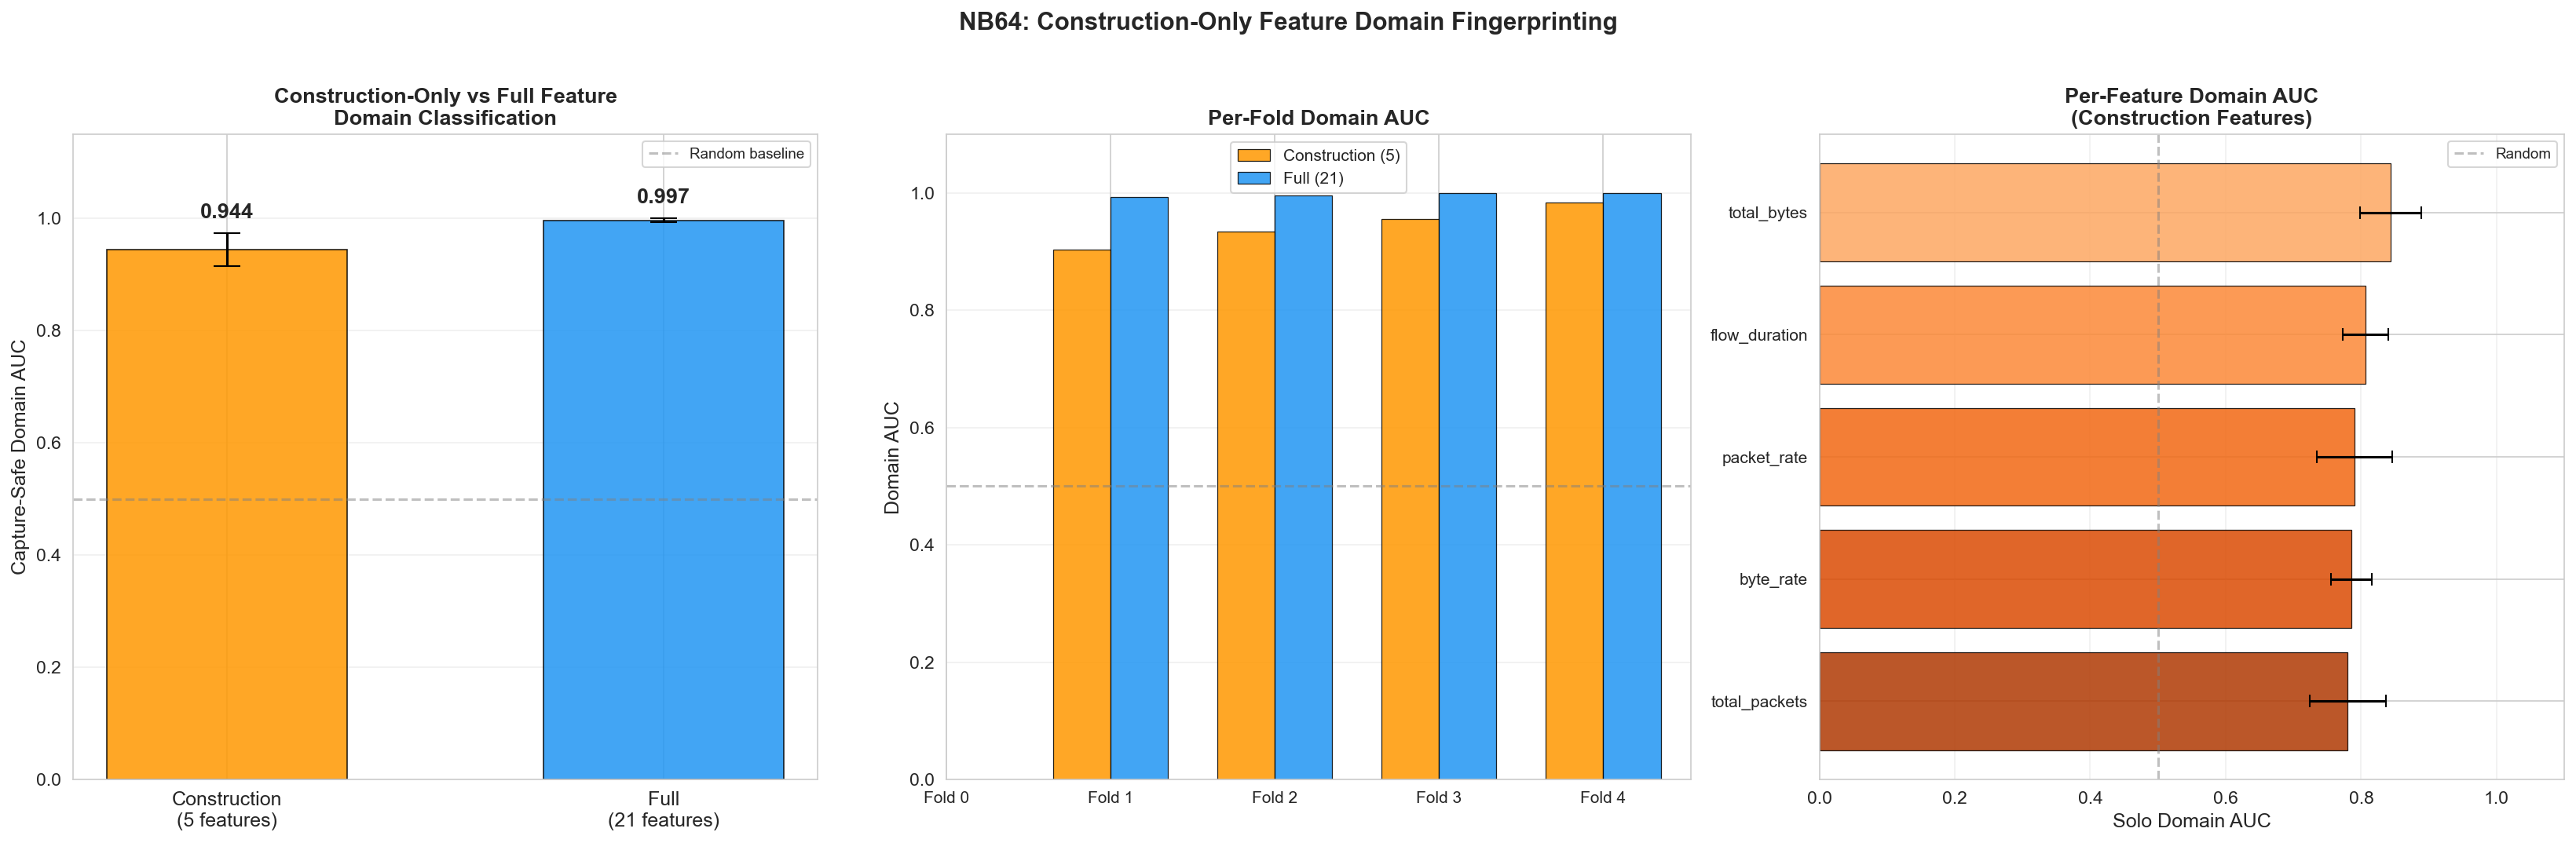


---
### 🖼 {_p.stem.replace("_", " ").title()}

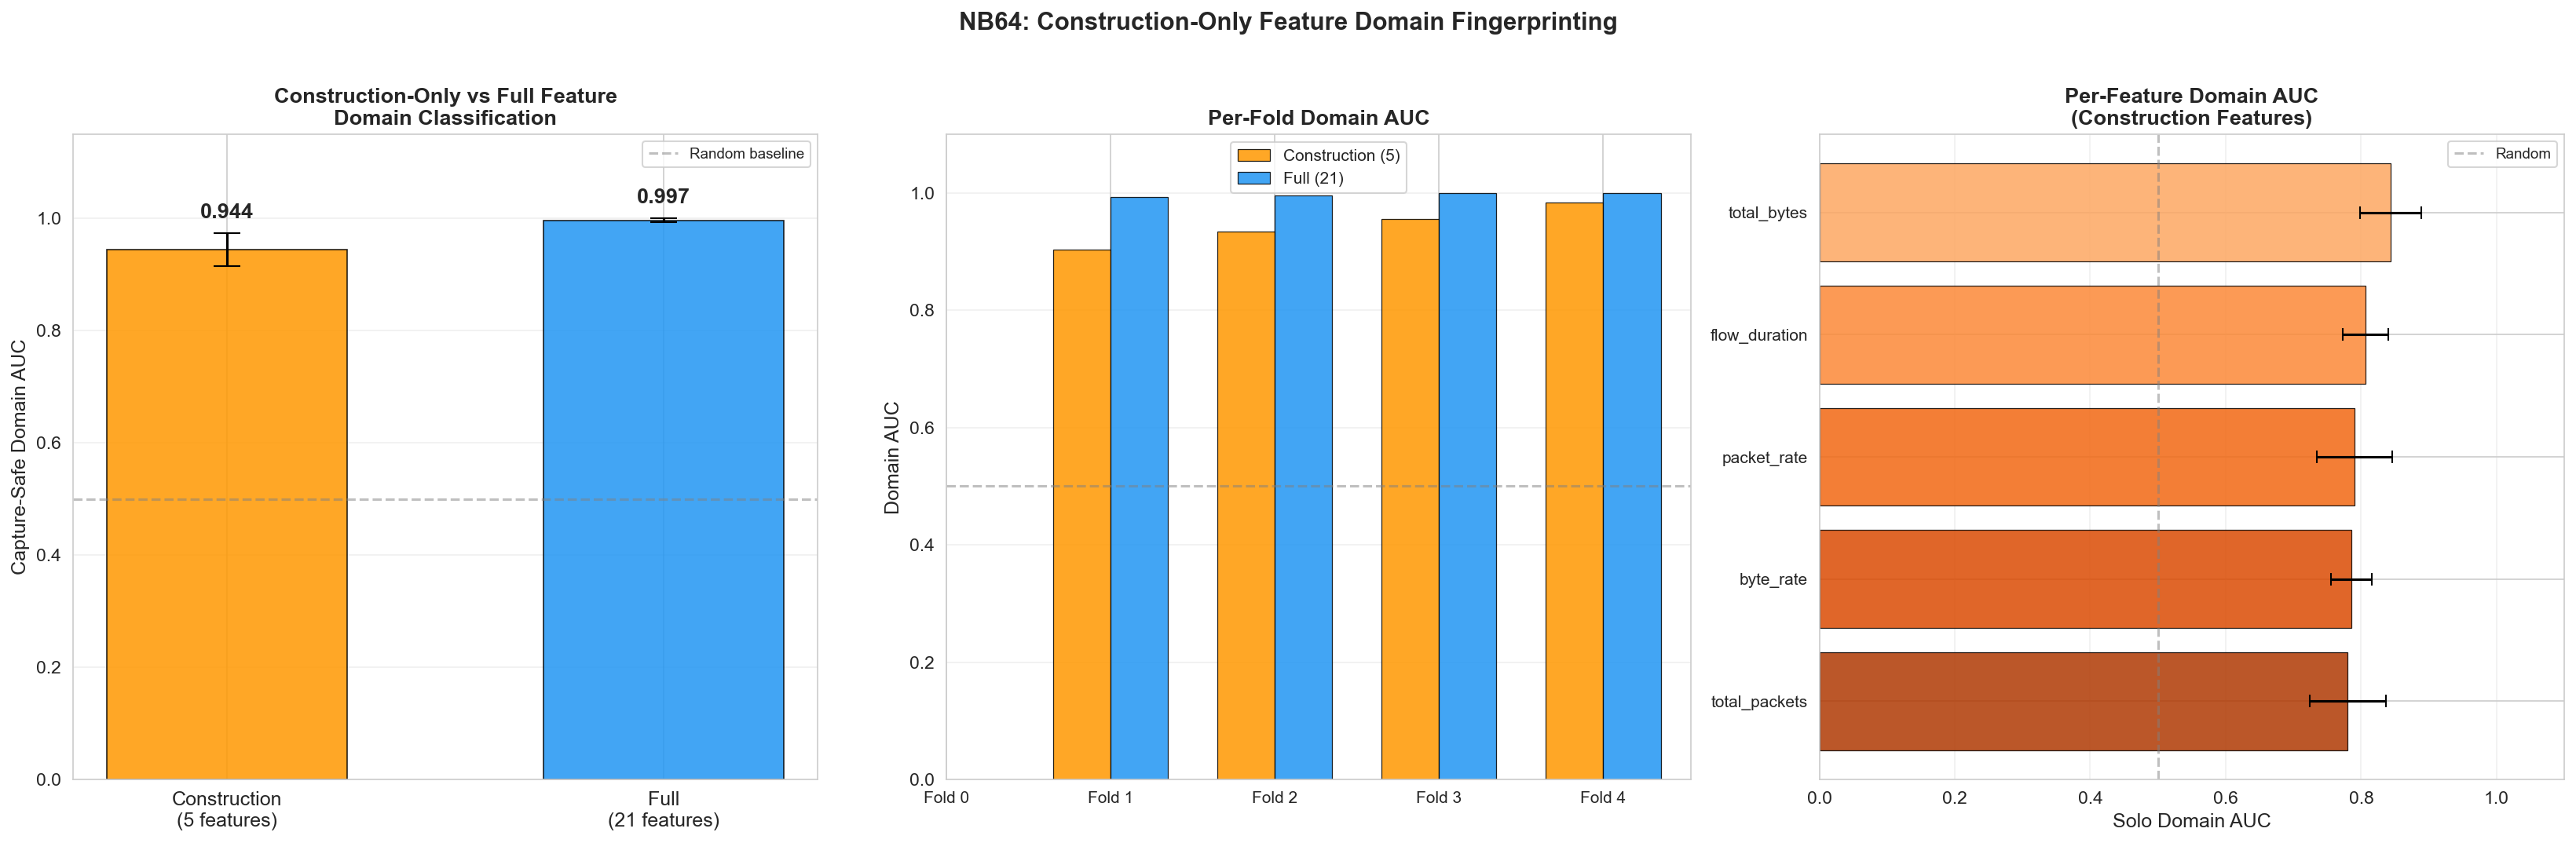


---
# 📋 Result Tables


### {_c.stem.replace("_", " ").title()}

,feature_set,n_features,fold,domain_auc,accuracy,n_train,n_test,n_train_captures,n_test_captures
0,construction_only,5,0,N/A,0.7487,31577,41035,339,1
1,construction_only,5,1,0.9028,0.8679,64717,7895,256,84
2,construction_only,5,2,0.9334,0.7841,64718,7894,255,85
3,construction_only,5,3,0.9551,0.7397,64718,7894,255,85
4,construction_only,5,4,0.9835,0.9180,64718,7894,255,85
5,full_21,21,0,N/A,0.9579,31577,41035,339,1
6,full_21,21,1,0.9924,0.9557,64717,7895,256,84
7,full_21,21,2,0.9956,0.9549,64718,7894,255,85
8,full_21,21,3,0.9990,0.9769,64718,7894,255,85
9,full_21,21,4,0.9995,0.9837,64718,7894,255,85


### {_c.stem.replace("_", " ").title()}

,feature,domain_auc,std
0,total_bytes,0.8434,0.0452
1,flow_duration,0.8065,0.0336
2,packet_rate,0.7903,0.0559
3,byte_rate,0.7854,0.0301
4,total_packets,0.7802,0.0562



---
### 🏁 {_j.stem.replace("_", " ").title()}

```json
{
  "notebook": "NB64",
  "title": "Construction-Only Feature Domain Fingerprinting",
  "datasets": [
    "iscx",
    "usbvpn",
    "vnat"
  ],
  "construction_features": [
    "flow_duration",
    "total_packets",
    "total_bytes",
    "packet_rate",
    "byte_rate"
  ],
  "n_construction": 5,
  "n_full": 21,
  "construction_domain_auc": 0.943694445521856,
  "construction_domain_auc_std": 0.02952663011142626,
  "full_domain_auc": 0.9966233529393619,
  "full_domain_auc_std": 0.0028713754137247053,
  "ratio": 0.9468917648162652,
  "delta": -0.05292890741750589,
  "interpretation": "STRONG: Construction features alone achieve near-perfect domain classification. The flow construction pipeline encodes dataset identity at the most fundamental level.",
  "solo_feature_ranking": [
    {
      "feature": "total_bytes",
      "domain_auc": 0.8434036373647935,
      "std": 0.04519703713963776
    },
    {
      "feature": "flow_duration",
      "domain_auc": 0.8065044608040216,
      "std": 0.03358117953973649
    },
    {
      "feature": "packet_rate",
      "domain_auc": 0.7903338330434564,
      "std": 0.05586163570190826
    },
    {
      "feature": "byte_rate",
      "domain_auc": 0.7854053554121347,
      "std": 0.030125770452260024
    },
    {
      "feature": "total_packets",
      "domain_auc": 0.7802363433596452,
      "std": 0.056160642465201145
    }
  ],
  "cv_config": {
    "method": "GroupKFold",
    "groups": "capture_id",
    "n_splits": 5,
    "n_estimators": 200,
    "seed": 42
  }
}
```


✅ NB64 gallery complete.


In [9]:
# ── Results Gallery: NB64 — Display all figures and tables ────────
import json, warnings
from pathlib import Path
from IPython.display import display, Image, Markdown
import pandas as pd

warnings.filterwarnings('ignore')

# Resolve output directory
if 'OUT' not in dir() and 'OUT_DIR' not in dir():
    ROOT = Path.cwd()
    if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
        ROOT = ROOT.parent
    _gallery_dir = ROOT / "artifacts" / "thesis_finalization" / "nb64_construction_only_domain_fingerprinting"
else:
    _gallery_dir = Path(str(OUT)) if 'OUT' in dir() else Path(str(OUT_DIR))

# Also check for a figures/ subdirectory
_fig_dir = _gallery_dir / 'figures'

# Collect all PNGs
_pngs = sorted(_gallery_dir.glob('*.png'))
if _fig_dir.exists():
    _pngs += sorted(_fig_dir.glob('*.png'))
_pngs = sorted(set(_pngs), key=lambda p: p.name)

# Collect all CSVs
_csvs = sorted(_gallery_dir.glob('*.csv'))

display(Markdown(f'# \U0001f4ca NB64 Results Gallery — {len(_pngs)} figures, {len(_csvs)} tables'))

# ── Display all PNG figures ──
if _pngs:
    for _p in _pngs:
        display(Markdown(f'\n---\n### \U0001f5bc {{_p.stem.replace("_", " ").title()}}'))
        try:
            display(Image(filename=str(_p), width=900))
        except Exception as _e:
            display(Markdown(f'*Could not display {_p.name}: {_e}*'))
else:
    display(Markdown('*No PNG files found in gallery directory. Run notebook cells first.*'))

# ── Display all CSV tables ──
if _csvs:
    display(Markdown('\n---\n# \U0001f4cb Result Tables\n'))
    for _c in _csvs:
        try:
            _tbl = pd.read_csv(_c)
            display(Markdown(f'### {{_c.stem.replace("_", " ").title()}}'))
            for _col in _tbl.select_dtypes(include="float").columns:
                _tbl[_col] = _tbl[_col].map(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
            display(_tbl)
        except Exception as _e:
            display(Markdown(f'*Could not load {_c.name}: {_e}*'))

# ── Display JSON verdict if present ──
_jsons = sorted(_gallery_dir.glob('*verdict*.json')) + sorted(_gallery_dir.glob('*summary*.json'))
_jsons = sorted(set(_jsons), key=lambda p: p.name)
for _j in _jsons[:2]:
    try:
        _data = json.loads(_j.read_text(encoding='utf-8'))
        display(Markdown(f'\n---\n### \U0001f3c1 {{_j.stem.replace("_", " ").title()}}'))
        display(Markdown(f'```json\n{json.dumps(_data, indent=2, default=str)[:3000]}\n```'))
    except Exception:
        pass

print('\n\u2705 NB64 gallery complete.')
